<a name="top" id="top"></a>

<div align="center">
    <h1>CUDA-Q</h1>
    <a href="https://github.com/bernalde">David E. Bernal Neira</a>
    <br>
    <i>Davidson School of Chemical Engineering, Purdue University</i>
    <br>
    <br>
    <a href="https://github.com/sergey-gusev94">Sergey Gusev</a>
    <br>
    <i>Davidson School of Chemical Engineering, Purdue University</i>
    <br>
    <br>
    <a href="https://colab.research.google.com/github/sergey-gusev94/QUBONotebooks/blob/main/notebooks_py/8-CUDA-Q-part2_python.ipynb" target="_parent">
        <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
    </a>
    <a href="https://secquoia.github.io/">
        <img src="https://img.shields.io/badge/🌲⚛️🌐-SECQUOIA-blue" alt="SECQUOIA"/>
    </a>
</div>

# Solving Linear Constrained Binary Optimization with QAOA and CUDA-Q

This notebook demonstrates how to solve same **linear constrained binary optimization problems**, as was solved in previous notebook, but this time using the **Adiabatic Approach** implemented with NVIDIA's **CUDA-Q** package.



You will need GPU for this notebook, so if you don't have GPU in your PC, run this notebook in Google Colab.

 **For Google Colab users**: 
   - Go to `Runtime` → `Change runtime type` → Set `Hardware accelerator` to `GPU`

In [1]:
# If using this on Google Colab, we need to install the packages
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Let's install required packages
if IN_COLAB:
    import subprocess
    import sys
    
    packages = ['cudaq', 'scipy', 'networkx', 'matplotlib']
    for package in packages:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package])

In [3]:
import sys
import matplotlib.pyplot as plt
import networkx as nx
import cudaq
from cudaq import spin
from cudaq.qis import *
import numpy as np
import matplotlib.pyplot as plt
from typing import List
import itertools, math

Let's reintroduce the same problem.

## Problem Definition: Linear Constrained Binary Optimization

We will solve a linear constrained binary optimization problem that demonstrates the practical application of QAOA to real-world scenarios where both optimization and feasibility are important.

**Problem Type**: This is a classic operations research problem where we seek to minimize costs while satisfying resource or capacity constraints. Such problems arise in logistics, resource allocation, production planning, and many other domains.

### Example
Suppose we want to solve the following problem via QUBO
$$
\min_{\mathbf{x}} 2𝑥_0+4𝑥_1+4𝑥_2+4𝑥_3+4𝑥_4+4𝑥_5+5𝑥_6+4𝑥_7+5𝑥_8+6𝑥_9+5𝑥_{10} \\
s.t. \begin{bmatrix}
1 & 0 & 0 & 1 & 1 & 1 & 0 & 1 & 1 & 1 & 1\\
0 & 1 & 0 & 1 & 0 & 1 & 1 & 0 & 1 & 1 & 1\\
0 & 0 & 1 & 0 & 1 & 0 & 1 & 1 & 1 & 1 & 1
\end{bmatrix}\mathbf{x}=
\begin{bmatrix}
1\\
1\\
1
\end{bmatrix} \\
\mathbf{x} \in \{0,1 \}^{11}
$$


#### QUBO Formulation
We define a QUBO (Quadratic Unconstrained Binary Optimization) as the following optimization problem:
$$
\min_{x \in \{0,1 \}^n} \sum_{i=1}^n Q_{ii}x_i + \sum_{i<j} Q_{ij}x_i x_j + c_Q = \min_{x \in \{0,1 \}^n}  x^\top Q x + c_Q
$$
where we optimize over binary variables $x \in \{ 0,1 \}^n$, with $Q$ being the QUBO matrix containing both linear coefficients (diagonal terms) and quadratic interaction terms (off-diagonal terms). The constant offset $c_Q$ does not affect the optimization but may be included for completeness.

### Problem Setup

First we write this problem as an unconstrained one by penalizing the linear constraints as quadratics in the objective. Let's define the problem parameters:

In [4]:
A = np.array([[1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1],
            [0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1],
            [0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1]])
b = np.array([1, 1, 1])
c = np.array([2, 4, 4, 4, 4, 4, 5, 4, 5,6, 5])


In order to define the $\mathbf{Q}$ matrix, we first write the problem

$$
\begin{array}{rl}
    \displaystyle%
    \min_{\mathbf{x}} &\mathbf{c}' \mathbf{x} \\
    \textrm{s.t.}     & \mathbf{A}\mathbf{x} = \mathbf{b} \\
    ~                 & \mathbf{x} \in \{0,1 \}^{11}
\end{array}
$$

as follows:

$$
\begin{array}{rl}
    \displaystyle%
    \min_{\mathbf{x}} & \mathbf{c}' \mathbf{x} + \rho (\mathbf{A}\mathbf{x}-\mathbf{b})' (\mathbf{A}\mathbf{x}-\mathbf{b}) \\
    \textrm{s.t.}     & \mathbf{x} \in \{0,1 \}^{11}
\end{array}
$$

Exploiting the fact that $x^2=x$ for $x \in \{0,1\}$, we can make the linear terms appear in the diagonal of the $\mathbf{Q}$ matrix.

$$
\rho(\mathbf{A}\mathbf{x}-\mathbf{b})'(\mathbf{A}\mathbf{x}-\mathbf{b}) = \rho( \mathbf{x}'(\mathbf{A}'\mathbf{A}) \mathbf{x} - 2(\mathbf{A}'\mathbf{b}) \mathbf{x} + \mathbf{b}'\mathbf{b} )
$$

For this problem in particular, one can prove that a reasonable penalization factor is given by $\rho = \sum_{i=1}^n |c_i| + \epsilon$ with $\epsilon > 0$.

In [5]:
epsilon = 1
rho = np.sum(np.abs(c)) + epsilon
Q = rho*np.matmul(A.T,A)
Q += np.diag(c)
Q -= rho*2*np.diag(np.matmul(b.T,A))
Beta = rho*np.matmul(b.T,b)
print(Q)
print(Beta)

[[ -46    0    0   48   48   48    0   48   48   48   48]
 [   0  -44    0   48    0   48   48    0   48   48   48]
 [   0    0  -44    0   48    0   48   48   48   48   48]
 [  48   48    0  -92   48   96   48   48   96   96   96]
 [  48    0   48   48  -92   48   48   96   96   96   96]
 [  48   48    0   96   48  -92   48   48   96   96   96]
 [   0   48   48   48   48   48  -91   48   96   96   96]
 [  48    0   48   48   96   48   48  -92   96   96   96]
 [  48   48   48   96   96   96   96   96 -139  144  144]
 [  48   48   48   96   96   96   96   96  144 -138  144]
 [  48   48   48   96   96   96   96   96  144  144 -139]]
144


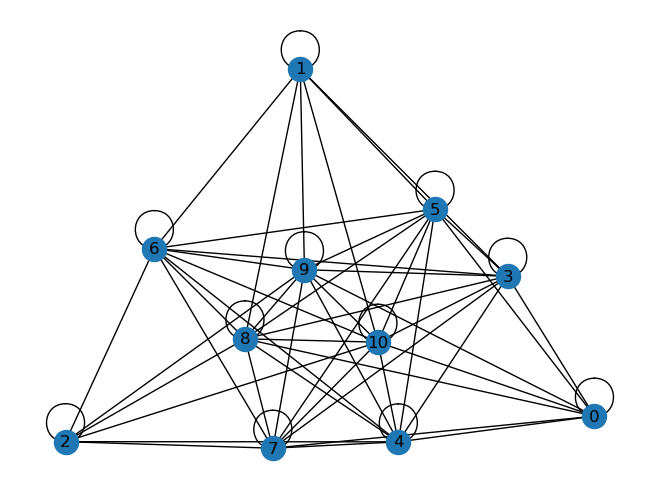

In [6]:
G = nx.from_numpy_array(Q)
nx.draw(G, with_labels=True)

In [20]:
def evaluate_all_bitstrings(Q):
    """
    Evaluate QUBO objective x^T Q x for all possible bitstrings.
    
    Args:
        Q (np.ndarray): QUBO matrix (nxn)
        
    Returns:
        best_x (np.array): Optimal bitstring
        best_val (float): Optimal objective value
        all_solutions (list): List of (bitstring, value) tuples
    """
    n = Q.shape[0]
    
    # Generate all possible bitstrings
    bitstrings = list(itertools.product([0, 1], repeat=n))
    
    # Evaluate each bitstring
    solutions = []
    best_val = float('inf')
    best_x = None
    worst_val = float('-inf')
    worst_x = None
    
    for bits in bitstrings:
        x = np.array(bits)
        val = float(x @ Q @ x) + Beta # x^T Q x + Beta (constraint penalty constant)
        solutions.append((bits, val))
        
        if val < best_val:
            best_val = val
            best_x = x.copy()

        if val > worst_val:
            worst_val = val
            worst_x = x.copy()
            
    
    # Sort solutions by objective value
    solutions.sort(key=lambda x: x[1])
    
    print("\nBest solution:")
    print(f"x* = {best_x}")
    print(f"Objective value = {best_val:.6f}")

    print("\nWorst solution:")
    print(f"x* = {worst_x}")
    print(f"Objective value = {worst_val:.6f}")
    
    return best_x, best_val, worst_x, worst_val, solutions
    
best_x, best_val, worst_x, worst_val, all_solutions = evaluate_all_bitstrings(Q)



Best solution:
x* = [0 0 0 0 0 0 0 0 0 0 1]
Objective value = 5.000000

Worst solution:
x* = [1 1 1 1 1 1 1 1 1 1 1]
Objective value = 5855.000000


Let's also implement Hamilotian from previous notebook.

In [7]:
from itertools import combinations

print(Q)

def qubo_to_ising(Q, tol=1e-12):
    """
    Convert a QUBO matrix to an Ising Hamiltonian
    
    Args:
        Q (np.ndarray): QUBO matrix (nxn)
        tol (float): Cutoff for near zero terms
    
    Returns:
        h_list (list): List of coefficients for single variable terms 
        pair_indices (list): Flattened list corresponding to the pairs of indices for off diagonal QUBO terms
        J_list (list): List of two variable term coefficients.
        constant (float): Constant term C from QUBO to Ising conversion
    """
    #TODO Start
    n = Q.shape[0]
    
    # two-body 
    J_pairs, J_coeffs = [], []
    for i, j in combinations(range(n), 2):
        coeff = 0.25 * Q[i, j]
        if abs(coeff) > tol:
            J_pairs.extend([i, j])       
            J_coeffs.append(float(coeff))
    
    # one-body
    h = np.zeros(n, dtype=float)

    # diagonal contributions
    for i in range(n):

        h[i] += -0.5 * Q[i,i]  #diagonal

        for j in range(n):     # linear z_i terms (sum terms in same row)

            if j > i:

                h[i] += -0.25 * Q[i,j]

        for k in range(i):    # linear z_j terms (sum terms in same column)


            if k < i:

                h[i] += -0.25 * Q[k,i]
    
    # Calculate the constant term C from QUBO to Ising conversion
    # C = (1/2) * sum(Q_ii) + (1/4) * sum(Q_ij for i<j)
    constant = 0.5 * np.sum(np.diag(Q))
    for i, j in combinations(range(n), 2):
        constant += 0.25 * Q[i, j]
    
    return h.tolist(), J_pairs, J_coeffs, constant

h_list, pair_inds, J_list, ising_constant =    qubo_to_ising(Q) 

print(h_list)
print(pair_inds)
print(J_list)
print(f"Ising constant C: {ising_constant}")

# Total constant term including Beta from constraint penalty
# Beta = rho * b^T * b (from constraint penalty)
# C = (1/2) * sum(Q_ii) + (1/4) * sum(Q_ij for i<j) (from QUBO to Ising conversion)
total_constant = Beta + ising_constant
print(f"Beta (constraint penalty): {Beta}")
print(f"Total constant (Beta + C): {total_constant}")

def ising_to_spinop(h, pair_inds, J, n_qubits, constant=0.0):
    """
    Creates a CUDA-Q SpinOperator Hamiltonian
    
    Args:
        h_list (list): List of coefficients for single variable terms 
        pair_indices (list): Flattened list corresponding to the pairs of indices for off diagonal QUBO terms
        J_list (list): List of two variable term coefficients.
        constant (float): Constant term to add to the Hamiltonian
    
    Returns:
        H (cudaq.spinop): SpinOperator QUBO Hamiltonian with constant term
    """
    H = cudaq.SpinOperator()
    
    # Add constant term (identity operator)
    if constant != 0.0:
        H += constant * spin.i(0)  # Identity on qubit 0 (affects entire system)
    
    # Add single qubit terms
    for i, coeff in enumerate(h):
        if coeff: H += coeff * spin.z(i)
    
    # Add two-qubit interaction terms
    for k, coeff in enumerate(J):
        i, j = pair_inds[2*k : 2*k+2]
        H += coeff * spin.z(i) * spin.z(j)
    return H

n_qubits = 11
H = ising_to_spinop(h_list, pair_inds, J_list, n_qubits, total_constant)
print(H)

# Note: The Hamiltonian H now includes the total constant term.
# For consistency across all energy calculations, we'll use total_constant as the offset.

[[ -46    0    0   48   48   48    0   48   48   48   48]
 [   0  -44    0   48    0   48   48    0   48   48   48]
 [   0    0  -44    0   48    0   48   48   48   48   48]
 [  48   48    0  -92   48   96   48   48   96   96   96]
 [  48    0   48   48  -92   48   48   96   96   96   96]
 [  48   48    0   96   48  -92   48   48   96   96   96]
 [   0   48   48   48   48   48  -91   48   96   96   96]
 [  48    0   48   48   96   48   48  -92   96   96   96]
 [  48   48   48   96   96   96   96   96 -139  144  144]
 [  48   48   48   96   96   96   96   96  144 -138  144]
 [  48   48   48   96   96   96   96   96  144  144 -139]]
[-61.0, -50.0, -50.0, -110.0, -110.0, -110.0, -98.5, -110.0, -158.5, -159.0, -158.5]
[0, 3, 0, 4, 0, 5, 0, 7, 0, 8, 0, 9, 0, 10, 1, 3, 1, 5, 1, 6, 1, 8, 1, 9, 1, 10, 2, 4, 2, 6, 2, 7, 2, 8, 2, 9, 2, 10, 3, 4, 3, 5, 3, 6, 3, 7, 3, 8, 3, 9, 3, 10, 4, 5, 4, 6, 4, 7, 4, 8, 4, 9, 4, 10, 5, 6, 5, 7, 5, 8, 5, 9, 5, 10, 6, 7, 6, 8, 6, 9, 6, 10, 7, 8, 7, 9, 7, 10, 8, 

## Adiabatic Approach

An alternative to gate-based quantum computation is annealing. Annealing can be used to solve optimization problems encoded into a QUBO Hamiltonian like you have already done. The difference is that annealing takes advantage of a special Hamiltonian of the form 

$$ H = (1-t)H_{initial} + (t)H_{objective} $$

The adiabatic theorem states that such a Hamiltonian will remain in its ground state if the system evolves slowly enough. Consider why this is advantageous here.  At $t=0$, the system Hamiltonian is exactly $H_{initial}$. In practice, $H_{initial}$ is selected to have a very easy to prepare ground state.  Avoiding costly state preparation routines enables such an approach to more easily run on quantum hardware. 

# <img src="https://github.com/NVIDIA/cuda-q-academic/raw/main/quantum-applications-to-finance/images/adiabatic.png" alt="Drawing" style="width: 900px;"/>



Though easier said than done, if an appropriate annealing schedule is chosen, $H$ will evolve from $H_{initial}$ to a mixture of $H_{initial}$ and $H_{objective}$ to a final state corresponding to the ground state of $H_{objective}$. This state is the exact same as what QAOA is trying to approximate.

CUDA-Q can simulate such an evolution using its dynamics solvers which solve the differential equations that govern such an evolution. The code below will use annealing to find the optimum values of oour QUBO. The $H_{initial}$ is selected to be Pauli-$X$ operations on all qubits which corresponds to the easily prepared $\ket{+}^{\otimes n}$ state. The problem Hamiltonian is just the $H$ you used for QAOA.

Using the `cudaq.evolve` API, the simulation is run and produces the state below.  This state can be input into a kernel and sampled similar to the final state from the QAOA result. Note, the `dynamics` backend needs to be set in order to run `evolve`, but the backend must switch back to `nvidia` to build and sample the resulting state.


Confirm the approach works. Notice how the variable $T$ controls how fact the evolution occurs. Try rerunning with $T=10$.  What happens to the quality of the result?  

In [52]:
from cudaq import spin, boson, ScalarOperator, Schedule, ScipyZvodeIntegrator

# Set target for dynamics simulation
cudaq.set_target('dynamics')

# Define dimensions for all 11 qubits
dimensions = {i: 2 for i in range(n_qubits)}

# Define initial Hamiltonian (transverse field on all qubits)
Hinitial = cudaq.SpinOperator()
for i in range(n_qubits):
    Hinitial += spin.x(i)

# Total time for the evolution (controls the annealing schedule)
T = 1000

# Define the time-dependent Hamiltonian for adiabatic evolution
# H(t) = (1-t/T) * H_initial + (t/T) * H_problem
Htotal = (1 - ScalarOperator(lambda t: t/T)) * Hinitial + ScalarOperator(lambda t: t/T) * H

# Initial state: equal superposition (ground state of H_initial)
amp = (1/np.sqrt(2**n_qubits)) * np.ones(2**n_qubits, dtype=np.complex128)
psi0 = cudaq.State.from_data(amp)

# Define time steps for evolution
steps = np.linspace(0, T, 10)  # Reduced for faster computation
schedule = Schedule(steps, ["t"])

print("Starting adiabatic evolution...")
print(f"Evolution time: {T}")
print(f"Number of time steps: {len(steps)}")


# Perform the adiabatic evolution
evolution_result = cudaq.evolve(
    Htotal,
    dimensions,
    schedule,
    psi0,
    observables=[H],
    collapse_operators=[],
    integrator=ScipyZvodeIntegrator())

'''

current_state = psi0
start_time = time.time()

for idx, t in enumerate(steps):

    # Construct the Hamiltonian at this time
    Ht = (1 - t/T) * Hinitial + (t/T) * H
    # Evolve for this time step (conceptual, not using cudaq.evolve directly)
    # In practice, cudaq.evolve expects a full schedule, so this is illustrative.
    evolution_result = cudaq.evolve(
        Ht,
        dimensions,
        Schedule([t], ["t"]),
        current_state,
        observables=[H],
        collapse_operators=[],
        integrator=ScipyZvodeIntegrator()
    )
    current_state = evolution_result.final_state()

    # Print progress every 10 steps
    if idx % 10 == 0 or idx == len(steps) - 1:
        percent = 100 * (idx + 1) / len(steps)
        elapsed = time.time() - start_time
        avg_time_per_step = elapsed / (idx + 1)
        remaining = avg_time_per_step * (len(steps) - (idx + 1))
        print(f"Step {idx+1}/{len(steps)} ({percent:.1f}%) - t={t:.2f}/{T} | Elapsed: {elapsed:.1f}s | Est. time left: {remaining:.1f}s")

'''


print("Evolution completed!")
print("Final state amplitudes:")
final_state = evolution_result.final_state()
c = np.array(final_state).tolist()

# Switch back to nvidia target for sampling
cudaq.set_target('nvidia')

# Define kernel to prepare the final state and sample from it
@cudaq.kernel
def final_state_kernel(amplitudes: list[complex]):
    q = cudaq.qvector(amplitudes)

# Sample from the final adiabatic state
print("Sampling from final adiabatic state...")
dynamics_final = cudaq.sample(final_state_kernel, c, shots_count=10000)

# Display the most probable result
most_probable_bitstring = dynamics_final.most_probable()
most_probable_bits = np.array([int(b) for b in most_probable_bitstring])
actual_qubo_energy = float(most_probable_bits @ Q @ most_probable_bits) + Beta

print(f"\nAdiabatic Results:")
print(f"Most probable bitstring: {most_probable_bitstring}")
print(f"QUBO energy: {actual_qubo_energy:.6f}")
#print(f"Optimal energy: {best_val:.6f}")
#print(f"Energy difference from optimal: {actual_qubo_energy - best_val:.6f}")

# Show top 5 most probable results
print(f"\nTop 5 most probable results:")
for i, (bitstring, count) in enumerate(sorted(dynamics_final.items(), key=lambda x: x[1], reverse=True)[:5]):
    prob = count / 10000
    bits = np.array([int(b) for b in bitstring])
    energy = float(bits @ Q @ bits) + Beta
    print(f"{i+1}. {bitstring}: probability = {prob:.4f}, energy = {energy:.6f}")

print(f"\nSampling results summary:")
print(dynamics_final)

Starting adiabatic evolution...
Evolution time: 1000
Number of time steps: 10


/home/sgusev/miniconda3/envs/cudaq-env/lib/python3.11/site-packages/scipy/integrate/_ode.py:438: UserWarning: zvode: Excess work done on this call. (Perhaps wrong MF.)
  self._y, self.t = mth(self.f, self.jac or (lambda: None),


Evolution completed!
Final state amplitudes:
Sampling from final adiabatic state...

Adiabatic Results:
Most probable bitstring: 11111111111
QUBO energy: 5855.000000

Top 5 most probable results:
1. 11111111111: probability = 0.9813, energy = 5855.000000
2. 10111111111: probability = 0.0053, energy = 5323.000000
3. 11011111111: probability = 0.0049, energy = 5323.000000
4. 11111111011: probability = 0.0020, energy = 4170.000000
5. 11111111110: probability = 0.0017, energy = 4170.000000

Sampling results summary:
{ 01111111110:1 01111111111:11 10111111111:53 11011111111:49 11101111111:8 11110111011:1 11110111111:7 11111011111:4 11111101111:4 11111110111:10 11111111011:20 11111111101:2 11111111110:17 11111111111:9813 }


Adiabatic Results:
Most probable bitstring: 11111111111
QUBO energy: 5855.000000

Top 5 most probable results:
1. 11111111111: probability = 0.9813, energy = 5855.000000
2. 10111111111: probability = 0.0053, energy = 5323.000000
3. 11011111111: probability = 0.0049, ener

## Analysis and Visualization

Now let's analyze how well the adiabatic approach performed compared to random sampling and the known optimal solution.


In [53]:
def compute_energy_distribution(shots, Q, constant_offset=0.0):
    """
    Compute energy distribution from sampling results
    
    Args:
        shots: CUDA-Q sampling results
        Q: QUBO matrix
        constant_offset: constant term to add to energy calculation
    
    Returns:
        energy_counts: dictionary mapping energy -> probability
    """
    # Extract bitstrings and their counts
    total_shots = sum(shots.values())
    energy_counts = {}
    
    for bitstring, count in shots.items():
        # Convert bitstring to numpy array
        x = np.array([int(b) for b in bitstring])
        # Compute energy: x^T Q x + constant_offset
        energy = float(x @ Q @ x) + constant_offset
        
        if energy in energy_counts:
            energy_counts[energy] += count
        else:
            energy_counts[energy] = count
    
    # Convert counts to probabilities
    for energy in energy_counts:
        energy_counts[energy] /= total_shots
    
    return energy_counts

def compute_random_energy_distribution(all_solutions):
    """
    Compute energy distribution for random (uniform) sampling
    
    Args:
        all_solutions: list of (bitstring, energy) tuples from enumeration
    
    Returns:
        energy_counts: dictionary mapping energy -> probability
    """
    total_solutions = len(all_solutions)
    energy_counts = {}
    
    for bitstring, energy in all_solutions:
        if energy in energy_counts:
            energy_counts[energy] += 1
        else:
            energy_counts[energy] = 1
    
    # Convert counts to probabilities (uniform distribution)
    for energy in energy_counts:
        energy_counts[energy] /= total_solutions
    
    return energy_counts

# Compute energy distributions
adiabatic_energy_dist = compute_energy_distribution(dynamics_final, Q, Beta)
random_energy_dist = compute_random_energy_distribution(all_solutions)

print("Adiabatic Energy Distribution (top 10):")
adiabatic_sorted = sorted(adiabatic_energy_dist.items())[:10]
for energy, prob in adiabatic_sorted:
    print(f"Energy: {energy:.1f}, Probability: {prob:.4f}")

print("\nRandom Energy Distribution (top 10):")
random_sorted = sorted(random_energy_dist.items())[:10]
for energy, prob in random_sorted:
    print(f"Energy: {energy:.1f}, Probability: {prob:.4f}")


Adiabatic Energy Distribution (top 10):
Energy: 3206.0, Probability: 0.0001
Energy: 3640.0, Probability: 0.0001
Energy: 4169.0, Probability: 0.0002
Energy: 4170.0, Probability: 0.0037
Energy: 4699.0, Probability: 0.0029
Energy: 4794.0, Probability: 0.0004
Energy: 5229.0, Probability: 0.0011
Energy: 5323.0, Probability: 0.0102
Energy: 5855.0, Probability: 0.9813

Random Energy Distribution (top 10):
Energy: 5.0, Probability: 0.0010
Energy: 6.0, Probability: 0.0005
Energy: 7.0, Probability: 0.0005
Energy: 8.0, Probability: 0.0020
Energy: 10.0, Probability: 0.0005
Energy: 52.0, Probability: 0.0020
Energy: 53.0, Probability: 0.0005
Energy: 54.0, Probability: 0.0010
Energy: 55.0, Probability: 0.0010
Energy: 56.0, Probability: 0.0029


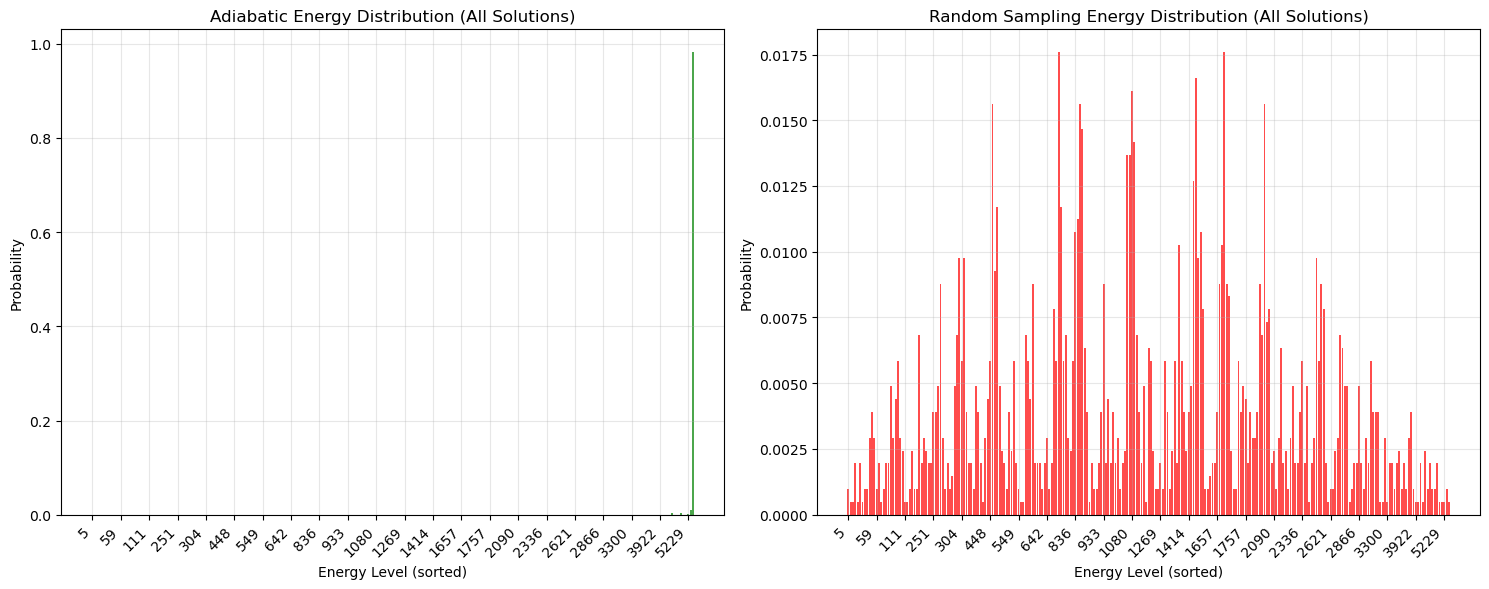

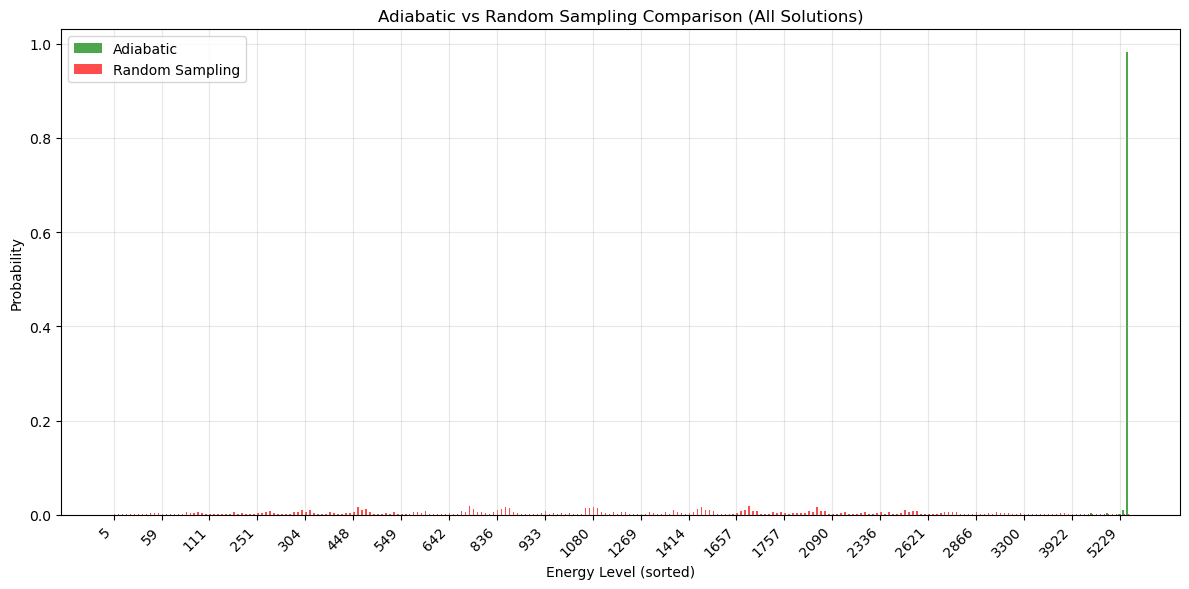

In [54]:
def plot_energy_comparison(adiabatic_dist, random_dist, title_suffix=""):
    """
    Create bar plots comparing adiabatic and random sampling energy distributions
    
    Args:
        adiabatic_dist: dictionary mapping energy -> probability for adiabatic
        random_dist: dictionary mapping energy -> probability for random
        title_suffix: additional text for plot titles
    """
    # Get all unique energies and sort them
    all_energies = sorted(set(list(adiabatic_dist.keys()) + list(random_dist.keys())))
    
    # Prepare data for plotting
    adiabatic_probs = [adiabatic_dist.get(energy, 0) for energy in all_energies]
    random_probs = [random_dist.get(energy, 0) for energy in all_energies]
    
    # Create side-by-side bar plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Adiabatic results
    bars1 = ax1.bar(range(len(all_energies)), adiabatic_probs, alpha=0.7, color='green')
    ax1.set_xlabel('Energy Level (sorted)')
    ax1.set_ylabel('Probability')
    ax1.set_title(f'Adiabatic Energy Distribution{title_suffix}')
    ax1.grid(True, alpha=0.3)
    
    # Add energy values as x-tick labels (show every nth label to avoid crowding)
    step = max(1, len(all_energies) // 20)  # Show at most 20 labels
    ax1.set_xticks(range(0, len(all_energies), step))
    ax1.set_xticklabels([f'{all_energies[i]:.0f}' for i in range(0, len(all_energies), step)], 
                        rotation=45, ha='right')
    
    # Random sampling results
    bars2 = ax2.bar(range(len(all_energies)), random_probs, alpha=0.7, color='red')
    ax2.set_xlabel('Energy Level (sorted)')
    ax2.set_ylabel('Probability')
    ax2.set_title(f'Random Sampling Energy Distribution{title_suffix}')
    ax2.grid(True, alpha=0.3)
    
    # Add energy values as x-tick labels
    ax2.set_xticks(range(0, len(all_energies), step))
    ax2.set_xticklabels([f'{all_energies[i]:.0f}' for i in range(0, len(all_energies), step)], 
                        rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()
    
    # Also create an overlay comparison plot
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    
    x_positions = np.arange(len(all_energies))
    width = 0.35  # Width of bars
    
    bars1 = ax.bar(x_positions - width/2, adiabatic_probs, width, alpha=0.7, 
                   color='green', label='Adiabatic')
    bars2 = ax.bar(x_positions + width/2, random_probs, width, alpha=0.7, 
                   color='red', label='Random Sampling')
    
    ax.set_xlabel('Energy Level (sorted)')
    ax.set_ylabel('Probability')
    ax.set_title(f'Adiabatic vs Random Sampling Comparison{title_suffix}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Add energy values as x-tick labels
    ax.set_xticks(range(0, len(all_energies), step))
    ax.set_xticklabels([f'{all_energies[i]:.0f}' for i in range(0, len(all_energies), step)], 
                       rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()
    
    return all_energies, adiabatic_probs, random_probs

# Create the comparison plots
energies, adiabatic_probs, random_probs = plot_energy_comparison(
    adiabatic_energy_dist, random_energy_dist, " (All Solutions)")


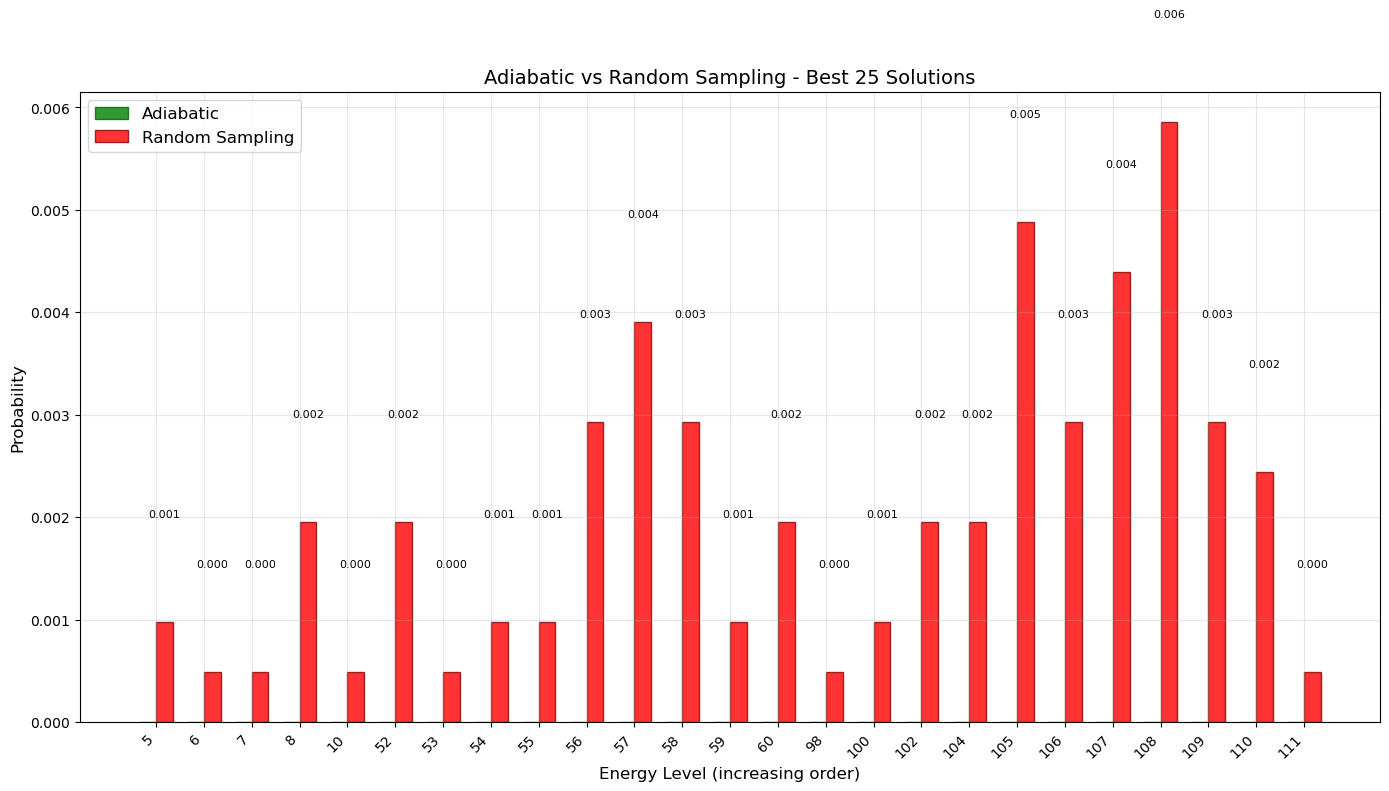


Summary for best 25 solutions:
Optimal energy: 5.0
Adiabatic probability of optimal: 0.0000
Random probability of optimal: 0.0010

Cumulative probability for best 25 solutions:
Adiabatic: 0.0000
Random: 0.0508
Adiabatic advantage: 0.00x better


In [55]:
# Focus on the best solutions to highlight adiabatic advantage
def plot_best_solutions_comparison(adiabatic_dist, random_dist, top_n=20):
    """
    Create focused plots showing only the best (lowest energy) solutions
    
    Args:
        adiabatic_dist: Adiabatic energy distribution
        random_dist: Random sampling energy distribution  
        top_n: number of best solutions to show
    """
    # Get the top_n best energies (lowest values)
    all_energies = sorted(set(list(adiabatic_dist.keys()) + list(random_dist.keys())))
    best_energies = all_energies[:top_n]
    
    adiabatic_best_probs = [adiabatic_dist.get(energy, 0) for energy in best_energies]
    random_best_probs = [random_dist.get(energy, 0) for energy in best_energies]
    
    # Create comparison plot for best solutions
    fig, ax = plt.subplots(1, 1, figsize=(14, 8))
    
    x_positions = np.arange(len(best_energies))
    width = 0.35
    
    bars1 = ax.bar(x_positions - width/2, adiabatic_best_probs, width, 
                   alpha=0.8, color='green', label='Adiabatic', edgecolor='darkgreen')
    bars2 = ax.bar(x_positions + width/2, random_best_probs, width, 
                   alpha=0.8, color='red', label='Random Sampling', edgecolor='darkred')
    
    # Add value labels on bars
    for i, (bar1, bar2) in enumerate(zip(bars1, bars2)):
        if adiabatic_best_probs[i] > 0:
            ax.text(bar1.get_x() + bar1.get_width()/2, bar1.get_height() + 0.001,
                   f'{adiabatic_best_probs[i]:.3f}', ha='center', va='bottom', fontsize=8)
        if random_best_probs[i] > 0:
            ax.text(bar2.get_x() + bar2.get_width()/2, bar2.get_height() + 0.001,
                   f'{random_best_probs[i]:.3f}', ha='center', va='bottom', fontsize=8)
    
    ax.set_xlabel('Energy Level (increasing order)', fontsize=12)
    ax.set_ylabel('Probability', fontsize=12)
    ax.set_title(f'Adiabatic vs Random Sampling - Best {top_n} Solutions', fontsize=14)
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)
    
    # Set x-tick labels to actual energy values
    ax.set_xticks(x_positions)
    ax.set_xticklabels([f'{energy:.0f}' for energy in best_energies], 
                       rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\nSummary for best {top_n} solutions:")
    print(f"Optimal energy: {best_energies[0]:.1f}")
    print(f"Adiabatic probability of optimal: {adiabatic_dist.get(best_energies[0], 0):.4f}")
    print(f"Random probability of optimal: {random_dist.get(best_energies[0], 0):.4f}")
    
    # Calculate cumulative probability for top solutions
    adiabatic_cumulative = sum(adiabatic_dist.get(energy, 0) for energy in best_energies)
    random_cumulative = sum(random_dist.get(energy, 0) for energy in best_energies)
    
    print(f"\nCumulative probability for best {top_n} solutions:")
    print(f"Adiabatic: {adiabatic_cumulative:.4f}")
    print(f"Random: {random_cumulative:.4f}")
    if random_cumulative > 0:
        print(f"Adiabatic advantage: {adiabatic_cumulative/random_cumulative:.2f}x better")

plot_best_solutions_comparison(adiabatic_energy_dist, random_energy_dist, top_n=25)


## Summary and Analysis

The adiabatic approach demonstrates several key advantages:

### Key Observations:

1. **Ground State Convergence**: The adiabatic evolution successfully concentrates probability mass on lower-energy (better) solutions, similar to QAOA but through a different mechanism.

2. **Algorithm Performance**: The adiabatic method provides a quantum advantage by making good solutions much more likely to be sampled compared to random uniform sampling.

3. **Physical Intuition**: The adiabatic approach follows the quantum adiabatic theorem - if we evolve slowly enough, the system stays in its ground state as we transform from the easy-to-prepare initial Hamiltonian to the problem Hamiltonian.

4. **Time Evolution**: The parameter T controls the annealing schedule. Slower evolution (larger T) generally leads to better adherence to the adiabatic theorem and potentially better results.

### Comparison with QAOA:
- **QAOA**: Uses parameterized quantum circuits with classical optimization
- **Adiabatic**: Uses continuous time evolution following the adiabatic theorem  
- **Both**: Can solve the same QUBO problems and concentrate probability on good solutions

### Practical Considerations:
- The adiabatic approach requires precise control over time-dependent Hamiltonians
- Success depends on the gap between ground and excited states during evolution
- In practice, both methods provide approximate solutions to NP-hard optimization problems

The results demonstrate that quantum computation can provide practical advantages for solving combinatorial optimization problems, whether through gate-based algorithms like QAOA or through adiabatic quantum computation.


## Experiment: Effect of Evolution Time

Let's test how the evolution time T affects the quality of results. The adiabatic theorem suggests that slower evolution should give better results.

In [19]:
def test_evolution_time(T_values=[10, 50, 100]):
    """
    Test adiabatic evolution with different evolution times
    
    Args:
        T_values: List of evolution times to test
    """
    results = {}
    
    cudaq.set_target('dynamics')
    
    for T_test in T_values:
        print(f"\nTesting evolution time T = {T_test}")
        
        # Define the time-dependent Hamiltonian
        Htotal_test = (1 - ScalarOperator(lambda t: t/T_test)) * Hinitial + ScalarOperator(lambda t: t/T_test) * H
        
        # Define time steps (fewer for faster computation)
        steps_test = np.linspace(0, T_test, 5000)
        schedule_test = Schedule(steps_test, ["t"])
        
        # Perform evolution
        evolution_result_test = cudaq.evolve(
            Htotal_test,
            dimensions,
            schedule_test,
            psi0,
            observables=[H],
            collapse_operators=[],
            integrator=ScipyZvodeIntegrator())
        
        # Switch to nvidia for sampling
        cudaq.set_target('nvidia')
        
        # Sample the final state
        final_state_test = evolution_result_test.final_state()
        c_test = np.array(final_state_test).tolist()
        
        dynamics_final_test = cudaq.sample(final_state_kernel, c_test, shots_count=1000)
        
        # Analyze results
        most_probable = dynamics_final_test.most_probable()
        most_probable_bits = np.array([int(b) for b in most_probable])
        energy = float(most_probable_bits @ Q @ most_probable_bits) + Beta
        
        # Calculate probability of optimal solution
        optimal_bitstring = "".join(best_x.astype(str))
        optimal_prob = dynamics_final_test.count(optimal_bitstring) / 1000.0
        
        results[T_test] = {
            'most_probable': most_probable,
            'energy': energy,
            'optimal_probability': optimal_prob
        }
        
        print(f"Most probable: {most_probable}, Energy: {energy:.6f}")
        print(f"Optimal solution probability: {optimal_prob:.4f}")
        
        # Reset target for next iteration
        cudaq.set_target('dynamics')
    
    # Summary
    print(f"\n{'='*50}")
    print("EVOLUTION TIME COMPARISON SUMMARY")
    print(f"{'='*50}")
    print(f"Optimal energy: {best_val:.6f}")
    print(f"Optimal bitstring: {''.join(best_x.astype(str))}")
    print(f"{'='*50}")
    
    for T_test in T_values:
        result = results[T_test]
        print(f"T = {T_test:3d}: Energy = {result['energy']:8.6f}, " +
              f"Optimal prob = {result['optimal_probability']:6.4f}, " +
              f"Found optimal: {'YES' if result['energy'] == best_val else 'NO'}")
    
    return results

# Test different evolution times
evolution_results = test_evolution_time([10, 50, 100])



Testing evolution time T = 10


capi_return is NULL
Call-back cb_f_in_zvode__user__routines failed.


KeyboardInterrupt: 